# Load and inspect the Dataset 

In [400]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

Set Visualization Style


In [401]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

Load The Dataset


In [402]:
df = pd.read_csv('games.csv', index_col = 0)

Dataset Overview


In [403]:
print("DATASET OVERVIEW")
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nFirst few rows:")
df.head()

DATASET OVERVIEW
Dataset shape: (1512, 13)

Column names and types:
Title                    str
Release Date             str
Team                     str
Rating               float64
Times Listed             str
Number of Reviews        str
Genres                   str
Summary                  str
Reviews                  str
Plays                    str
Playing                  str
Backlogs                 str
Wishlist                 str
dtype: object

First few rows:


,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,Hades,"Dec 10, 2019",['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,Undertale,"Sep 15, 2015","['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K
4,Hollow Knight,"Feb 24, 2017",['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K


Checking for Missing Values and data Quality Issues

In [404]:
print("\n" + "=" * 80)
print("DATA QUALITY ASSESSMENT")
print("=" * 80)
print("\nMissing values per column:")
print(df.isnull().sum())
print(f"\nMissing values percentage:")
print((df.isnull().sum() / len(df) * 100).round(2))



DATA QUALITY ASSESSMENT

Missing values per column:
Title                 0
Release Date          0
Team                  1
Rating               13
Times Listed          0
Number of Reviews     0
Genres                0
Summary               1
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
dtype: int64

Missing values percentage:
Title                0.00
Release Date         0.00
Team                 0.07
Rating               0.86
Times Listed         0.00
Number of Reviews    0.00
Genres               0.00
Summary              0.07
Reviews              0.00
Plays                0.00
Playing              0.00
Backlogs             0.00
Wishlist             0.00
dtype: float64


In [405]:
print("\n" + "-" * 80)
print("SAMPLE DATA - Showing potential data quality issues:")
print("-" * 80)
print("\nSample Release Dates (messy format):")
print(df['Release Date'].head(10))
print("\nSample Team data (nested lists):")
print(df['Team'].head(5))
print("\nSample Genres data (nested lists):")
print(df['Genres'].head(5))
print("\nSample Rating values:")
print(df['Rating'].head(10))
print(f"Rating range: {df['Rating'].min()} - {df['Rating'].max()}")


--------------------------------------------------------------------------------
SAMPLE DATA - Showing potential data quality issues:
--------------------------------------------------------------------------------

Sample Release Dates (messy format):
0    Feb 25, 2022
1    Dec 10, 2019
2    Mar 03, 2017
3    Sep 15, 2015
4    Feb 24, 2017
5    Nov 18, 2011
6    Dec 25, 2020
7    Oct 07, 2021
8    Jun 15, 2018
9    Feb 23, 2017
Name: Release Date, dtype: str

Sample Team data (nested lists):
0       ['Bandai Namco Entertainment', 'FromSoftware']
1                                 ['Supergiant Games']
2    ['Nintendo', 'Nintendo EPD Production Group No...
3                                   ['tobyfox', '8-4']
4                                      ['Team Cherry']
Name: Team, dtype: str

Sample Genres data (nested lists):
0                                 ['Adventure', 'RPG']
1             ['Adventure', 'Brawler', 'Indie', 'RPG']
2                                 ['Adventure', 'RPG']
3 

Data Cleaning


In [406]:
import ast
from dateutil.parser import parse as parse_date
from sklearn.preprocessing import LabelEncoder

In [407]:
df_clean = df.copy()

Parse Nested List Columns Like Team And Genres

In [408]:
df_clean['Team'] = df_clean['Team'].apply(parse_list_column)
df_clean['Genres'] = df_clean['Genres'].apply(parse_list_column)

print("\nParsed Team and Genres columns")
print(f"Sample Team: {df_clean['Team'].iloc[0]}")
print(f"Sample Genres: {df_clean['Genres'].iloc[0]}")


Parsed Team and Genres columns
Sample Team: ['Bandai Namco Entertainment', 'FromSoftware']
Sample Genres: ['Adventure', 'RPG']


Convert Numberic Columns with K Suffix

<h6>Converting Values like 3.9K into Numeric </h6>

In [409]:
numeric_cols = ['Times Listed', 'Number of Reviews', 'Plays', 'Playing', 'Backlogs', 'Wishlist']
for col in numeric_cols:
    df_clean[col] = df_clean[col].apply(convert_k_to_numeric)

print("Converted numeric columns:")
print(df_clean[numeric_cols].head())

Converted numeric columns:
   Times Listed  Number of Reviews    Plays  Playing  Backlogs  Wishlist
0        3900.0             3900.0  17000.0   3800.0    4600.0    4800.0
1        2900.0             2900.0  21000.0   3200.0    6300.0    3600.0
2        4300.0             4300.0  30000.0   2500.0    5000.0    2600.0
3        3500.0             3500.0  28000.0    679.0    4900.0    1800.0
4        3000.0             3000.0  21000.0   2400.0    8300.0    2300.0


Clean Release Data

In [410]:
df_clean['Release_Year'] = df_clean['Release Date'].apply(extract_year_from_date)


Filling the Missing Years with Median

In [411]:
median_year = int(df_clean['Release_Year'].median())
df_clean['Release_Year'] = df_clean['Release_Year'].fillna(median_year).astype('Int64')

print(f"Release Year range: {df_clean['Release_Year'].min()} - {df_clean['Release_Year'].max()}")
print(f"Filled {df_clean['Release_Year'].isna().sum()} missing values with median year {median_year}")
print(f"\nRelease Year distribution:\n{df_clean['Release_Year'].value_counts().sort_index()}")

Release Year range: 1980 - 2025
Filled 0 missing values with median year 2014

Release Year distribution:
Release_Year
1980      1
1982      1
1985      1
1986      4
1987      3
1988      5
1989      5
1990      6
1991     11
1992      6
1993     12
1994     11
1995     12
1996     15
1997     18
1998     16
1999     25
2000     15
2001     30
2002     22
2003     26
2004     37
2005     41
2006     32
2007     50
2008     44
2009     40
2010     58
2011     50
2012     60
2013     68
2014     62
2015     73
2016     75
2017     70
2018     77
2019     87
2020     74
2021     97
2022    132
2023     38
2024      1
2025      1
Name: count, dtype: Int64


Feature Engineering From Categorical Columns

<h6> Number of Genres </h6>

In [412]:
df_clean['Num_Genres'] = df_clean['Genres'].apply(len)
print(f"Number of Genres: min={df_clean['Num_Genres'].min()}, "
      f"max={df_clean['Num_Genres'].max()}, mean={df_clean['Num_Genres'].mean():.2f}")

Number of Genres: min=0, max=7, mean=2.41


<h6> Get all unique genres  </h6>

In [413]:
all_genres = set()
for genres_list in df_clean['Genres']:
    all_genres.update(genres_list)
all_genres = sorted(list(all_genres))

print(f"\nTotal unique genres: {len(all_genres)}")
print(f"Genres: {all_genres}")


Total unique genres: 23
Genres: ['Adventure', 'Arcade', 'Brawler', 'Card & Board Game', 'Fighting', 'Indie', 'MOBA', 'Music', 'Pinball', 'Platform', 'Point-and-Click', 'Puzzle', 'Quiz/Trivia', 'RPG', 'Racing', 'Real Time Strategy', 'Shooter', 'Simulator', 'Sport', 'Strategy', 'Tactical', 'Turn Based Strategy', 'Visual Novel']


Create Binary Columns for top Games

In [414]:
top_genres = ['Adventure', 'RPG', 'Indie', 'Platform', 'Brawler', 'Puzzle']
for genre in top_genres:
    df_clean[f'Genre_{genre}'] = df_clean['Genres'].apply(lambda x: 1 if genre in x else 0)

print(f"\nGenre distribution:")
for genre in top_genres:
    count = df_clean[f'Genre_{genre}'].sum()
    print(f"  {genre}: {count} games ({count/len(df_clean)*100:.1f}%)")


Genre distribution:
  Adventure: 1014 games (67.1%)
  RPG: 523 games (34.6%)
  Indie: 284 games (18.8%)
  Platform: 329 games (21.8%)
  Brawler: 159 games (10.5%)
  Puzzle: 176 games (11.6%)


Handle Missing Values

In [415]:
print("\nMissing values before imputation:")
print(df_clean.isnull().sum())


Missing values before imputation:
Title                 0
Release Date          0
Team                  0
Rating               13
Times Listed          0
Number of Reviews     0
Genres                0
Summary               1
Reviews               0
Plays                 0
Playing               0
Backlogs              0
Wishlist              0
Release_Year          0
Num_Genres            0
Genre_Adventure       0
Genre_RPG             0
Genre_Indie           0
Genre_Platform        0
Genre_Brawler         0
Genre_Puzzle          0
dtype: int64


Fill Missing Values

In [416]:
df_clean['Times Listed'].fillna(df_clean['Times Listed'].median(), inplace=True)
df_clean['Number of Reviews'].fillna(df_clean['Number of Reviews'].median(), inplace=True)
df_clean['Plays'].fillna(df_clean['Plays'].median(), inplace=True)
df_clean['Playing'].fillna(df_clean['Playing'].median(), inplace=True)
df_clean['Backlogs'].fillna(df_clean['Backlogs'].median(), inplace=True)
df_clean['Wishlist'].fillna(df_clean['Wishlist'].median(), inplace=True)

0       4800.0
1       3600.0
2       2600.0
3       1800.0
4       2300.0
         ...  
1507      67.0
1508     107.0
1509     206.0
1510     602.0
1511      73.0
Name: Wishlist, Length: 1512, dtype: float64

 Rating Fill with Median 

In [417]:
median_rating = df_clean['Rating'].median()
df_clean['Rating'] = df_clean['Rating'].fillna(median_rating)

print(f"Missing ratings after: {df_clean['Rating'].isnull().sum()}")

Missing ratings after: 0


Filling The Summaries


In [418]:
print(f"Missing summaries before: {df_clean['Summary'].isnull().sum()}")

# Fill with empty string
df_clean['Summary'] = df_clean['Summary'].fillna('NA')

print(f"Missing summaries after: {df_clean['Summary'].isnull().sum()}")

Missing summaries before: 1
Missing summaries after: 0


Checking for Missing Values again

In [419]:
print(df_clean.isnull().sum())

Title                0
Release Date         0
Team                 0
Rating               0
Times Listed         0
Number of Reviews    0
Genres               0
Summary              0
Reviews              0
Plays                0
Playing              0
Backlogs             0
Wishlist             0
Release_Year         0
Num_Genres           0
Genre_Adventure      0
Genre_RPG            0
Genre_Indie          0
Genre_Platform       0
Genre_Brawler        0
Genre_Puzzle         0
dtype: int64


Create Target Variable for Classification 

In [420]:
print(f"\nRating Statistics (Regression Target):")
print(df_clean['Rating'].describe())


Rating Statistics (Regression Target):
count    1512.000000
mean        3.720040
std         0.530364
min         0.700000
25%         3.400000
50%         3.800000
75%         4.100000
max         4.800000
Name: Rating, dtype: float64


In [421]:
df_clean['High_Rated'] = (df_clean['Rating'] >= 4.0).astype(int)
print(f"\nClassification Target (High_Rated):")
print(f"  High rated (>=4.0): {(df_clean['High_Rated'] == 1).sum()} games ({(df_clean['High_Rated'] == 1).sum()/len(df_clean)*100:.1f}%)")
print(f"  Low rated (<4.0): {(df_clean['High_Rated'] == 0).sum()} games ({(df_clean['High_Rated'] == 0).sum()/len(df_clean)*100:.1f}%)")


Classification Target (High_Rated):
  High rated (>=4.0): 581 games (38.4%)
  Low rated (<4.0): 931 games (61.6%)


NLP Feature Extraction From Reviews

Importing Data

In [422]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

Dowload Required NLTK Data

In [423]:
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('vader_lexicon', quiet=True)

True

Initialize sntiment Analyzer

In [424]:
sia = SentimentIntensityAnalyzer()

Basic Review Text Processing

Removing White Space

In [425]:
def clean_text(text):
    """Clean and preprocess text"""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text) 
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [426]:
def get_review_statistics(review_text):
    """Extract basic statistics from review text"""
    if pd.isna(review_text) or review_text == "":
        return {"review_length": 0, "word_count": 0, "sentence_count": 0}
    
    text = str(review_text)
    words = word_tokenize(text.lower())
    sentences = sent_tokenize(text)
    
    return {
        "review_length": len(text),
        "word_count": len(words),
        "sentence_count": len(sentences),
        "avg_word_length": np.mean([len(w) for w in words]) if words else 0,
    }

In [427]:
review_stats = df_clean['Reviews'].apply(get_review_statistics)
review_stats_df = pd.DataFrame(review_stats.tolist())

In [428]:
df_clean['Review_Length'] = review_stats_df['review_length']
df_clean['Review_Word_Count'] = review_stats_df['word_count']
df_clean['Review_Sentence_Count'] = review_stats_df['sentence_count']
df_clean['Review_Avg_Word_Length'] = review_stats_df['avg_word_length']

print(f"Added review length features:")
print(f"  - Review_Length: mean={df_clean['Review_Length'].mean():.1f}")
print(f"  - Review_Word_Count: mean={df_clean['Review_Word_Count'].mean():.1f}")
print(f"  - Review_Sentence_Count: mean={df_clean['Review_Sentence_Count'].mean():.1f}")

Added review length features:
  - Review_Length: mean=1244.1
  - Review_Word_Count: mean=254.1
  - Review_Sentence_Count: mean=10.3


Sentiment Analysis

In [429]:
def get_sentiment_scores(text):
    """Extract sentiment scores using VADER and TextBlob"""
    if pd.isna(text) or text == "":
        return {
            "vader_compound": 0, "vader_pos": 0, "vader_neg": 0, "vader_neu": 0,
            "textblob_polarity": 0, "textblob_subjectivity": 0
        }
    
    # VADER sentiment (good for social media/short text)
    vader_scores = sia.polarity_scores(str(text))
    
    # TextBlob sentiment
    blob = TextBlob(str(text))
    
    return {
        "vader_compound": vader_scores['compound'],
        "vader_pos": vader_scores['pos'],
        "vader_neg": vader_scores['neg'],
        "vader_neu": vader_scores['neu'],
        "textblob_polarity": blob.sentiment.polarity,
        "textblob_subjectivity": blob.sentiment.subjectivity
    }


sentiment_scores = df_clean['Reviews'].apply(get_sentiment_scores)
sentiment_df = pd.DataFrame(sentiment_scores.tolist())


Add to DataFrame

In [430]:
for col in sentiment_df.columns:
    df_clean[f'Sentiment_{col}'] = sentiment_df[col]

print(f"Added sentiment features:")
print(f"  - Sentiment_vader_compound: min={df_clean['Sentiment_vader_compound'].min():.3f}, "
        f"max={df_clean['Sentiment_vader_compound'].max():.3f}")
print(f"  - Sentiment_textblob_polarity: mean={df_clean['Sentiment_textblob_polarity'].mean():.3f}")


Added sentiment features:
  - Sentiment_vader_compound: min=-0.996, max=1.000
  - Sentiment_textblob_polarity: mean=0.101


TF-IDF Feature Extraction

In [431]:
df_clean['Reviews_Cleaned'] = df_clean['Reviews'].apply(clean_text)

Vectorizer with N-grams

In [432]:
tfidf = TfidfVectorizer(
    max_features=100,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=2,
    max_df=0.95
)

Fit and Transform

In [433]:
tfidf_matrix = tfidf.fit_transform(df_clean['Reviews_Cleaned'].fillna(''))

Get Feature Names

In [434]:
tfidf_features = [f'TFIDF_{word}' for word in tfidf.get_feature_names_out()]

Convert to Data Frame

In [435]:
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_features, index=df_clean.index)

Add Top TF-IDF Features to Data Frame

In [436]:
top_n_tfidf = 20
important_tfidf_features = tfidf_features[:top_n_tfidf]
for feat in important_tfidf_features:
    df_clean[feat] = tfidf_df[feat]

print(f"Created {len(tfidf_features)} TF-IDF features, added top {top_n_tfidf} to dataframe")
print(f"Sample TF-IDF features: {important_tfidf_features[:5]}")

Created 100 TF-IDF features, added top 20 to dataframe
Sample TF-IDF features: ['TFIDF_actually', 'TFIDF_amazing', 'TFIDF_bad', 'TFIDF_bem', 'TFIDF_best']


USe Count Vectorizer for LDA 

In [437]:
count_vectorizer = CountVectorizer(
    max_features=500,
    stop_words='english',
    min_df=2,
    max_df=0.95
)

In [438]:
dtm = count_vectorizer.fit_transform(df_clean['Reviews_Cleaned'].fillna(''))

In [439]:
n_topics = 10
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=100)
topic_distribution = lda.fit_transform(dtm)

In [440]:
for i in range(n_topics):
    df_clean[f'Topic_{i}_Weight'] = topic_distribution[:, i]

print(f"Added {n_topics} topic weight features from LDA")

Added 10 topic weight features from LDA


In [441]:
feature_names = count_vectorizer.get_feature_names_out()
print("\nTop words per topic (interpretation):")
for topic_idx, topic in enumerate(lda.components_):
    top_words_idx = topic.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"  Topic {topic_idx}: {', '.join(top_words)}")


Top words per topic (interpretation):
  Topic 0: game, like, really, just, fun, great, games, lot, good, feel
  Topic 1: game, world, time, combat, games, beat, final, feel, based, fantasy
  Topic 2: game, best, games, good, story, series, time, like, pokemon, fun
  Topic 3: que, jogo, um, com, mas, muito, uma, em, mais, eu
  Topic 4: game, like, just, good, games, fun, really, play, time, played
  Topic 5: game, sonic, games, level, fun, just, time, levels, music, great
  Topic 6: mario, games, game, best, super, fun, controls, nintendo, series, make
  Topic 7: game, boss, man, design, really, just, fights, level, like, horror
  Topic 8: story, game, characters, really, combat, character, gameplay, fun, great, good
  Topic 9: que, la, el, es, en, juego, game, lo, pero, los


Review Complexity Features

In [442]:
def get_complexity_scores(text):
    """Extract text complexity metrics"""
    if pd.isna(text) or text == "":
        return {"unique_word_ratio": 0, "lexical_diversity": 0, "avg_word_complexity": 0}
    
    words = word_tokenize(str(text).lower())
    words = [w for w in words if w.isalpha()]
    
    if len(words) == 0:
        return {"unique_word_ratio": 0, "lexical_diversity": 0, "avg_word_complexity": 0}
    
    unique_words = set(words)
    
    return {
        "unique_word_ratio": len(unique_words) / len(words),
        "lexical_diversity": len(unique_words) / (len(words) ** 0.5) if len(words) > 0 else 0,
        "avg_word_complexity": np.mean([len(w) for w in words])
    }

complexity_scores = df_clean['Reviews'].apply(get_complexity_scores)
complexity_df = pd.DataFrame(complexity_scores.tolist())

for col in complexity_df.columns:
    df_clean[f'Complexity_{col}'] = complexity_df[col]

print(f"Added complexity features:")
print(f"  - Complexity_unique_word_ratio: mean={df_clean['Complexity_unique_word_ratio'].mean():.3f}")
print(f"  - Complexity_lexical_diversity: mean={df_clean['Complexity_lexical_diversity'].mean():.3f}")

Added complexity features:
  - Complexity_unique_word_ratio: mean=0.679
  - Complexity_lexical_diversity: mean=8.864


Keyword Extraction

In [443]:
positive_keywords = [
    'amazing', 'awesome', 'brilliant', 'excellent', 'fantastic', 'fun', 
    'great', 'innovative', 'interesting', 'love', 'masterpiece', 'perfect',
    'recommend', 'superb', 'wonderful', 'addictive', 'captivating', 'engaging'
]

negative_keywords = [
    'awful', 'bad', 'boring', 'broken', 'buggy', 'disappointing', 'glitchy',
    'hate', 'horrible', 'mediocre', 'poor', 'terrible', 'unplayable',
    'waste', 'worst', 'frustrating', 'laggy', 'repetitive'
]

def count_keywords(text, keyword_list):
    """Count occurrences of keywords in text"""
    if pd.isna(text) or text == "":
        return 0
    text = str(text).lower()
    count = 0
    for keyword in keyword_list:
        count += len(re.findall(r'\b' + re.escape(keyword) + r'\b', text))
    return count

df_clean['Positive_Keyword_Count'] = df_clean['Reviews'].apply(
    lambda x: count_keywords(x, positive_keywords)
)
df_clean['Negative_Keyword_Count'] = df_clean['Reviews'].apply(
    lambda x: count_keywords(x, negative_keywords)
)
df_clean['Keyword_Sentiment_Score'] = df_clean['Positive_Keyword_Count'] - df_clean['Negative_Keyword_Count']

print(f"Added keyword features:")
print(f"  - Positive_Keyword_Count: mean={df_clean['Positive_Keyword_Count'].mean():.2f}")
print(f"  - Negative_Keyword_Count: mean={df_clean['Negative_Keyword_Count'].mean():.2f}")


Added keyword features:
  - Positive_Keyword_Count: mean=2.58
  - Negative_Keyword_Count: mean=0.76


In [444]:

svd = TruncatedSVD(n_components=20, random_state=42)
review_embeddings = svd.fit_transform(tfidf_matrix)

for i in range(20):
    df_clean[f'Review_Embedding_{i}'] = review_embeddings[:, i]

print(f"Added 20 review embedding features (explained variance: {svd.explained_variance_ratio_.sum():.2%})")

print(f"Total columns after NLP: {len(df_clean.columns)}")

Added 20 review embedding features (explained variance: 41.67%)
Total columns after NLP: 89


Prepare Feature for modeling

In [445]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.svm import SVR, SVC
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
from xgboost import XGBRegressor, XGBClassifier
import lightgbm as lgb

In [446]:
numeric_base_cols = ['Times Listed', 'Number of Reviews', 'Plays', 'Playing', 'Backlogs', 'Wishlist']
categorical_derived_cols = ['Num_Developers', 'Num_Genres', 'Release_Year']
genre_cols = [col for col in df_clean.columns if col.startswith('Genre_')]


review_stats_cols = ['Review_Length', 'Review_Word_Count', 'Review_Sentence_Count', 'Review_Avg_Word_Length']
sentiment_cols = [col for col in df_clean.columns if col.startswith('Sentiment_')]
complexity_cols = [col for col in df_clean.columns if col.startswith('Complexity_')]
keyword_cols = ['Positive_Keyword_Count', 'Negative_Keyword_Count', 'Keyword_Sentiment_Score']
topic_cols = [col for col in df_clean.columns if col.startswith('Topic_')]
embedding_cols = [col for col in df_clean.columns if col.startswith('Review_Embedding_')]
tfidf_cols = [col for col in df_clean.columns if col.startswith('TFIDF_')]


features_no_nlp = numeric_base_cols + categorical_derived_cols + genre_cols
features_all_nlp = (review_stats_cols + sentiment_cols + complexity_cols + 
                    keyword_cols + topic_cols + embedding_cols + tfidf_cols)
features_all = features_no_nlp + features_all_nlp

print(f"Total features without NLP: {len(features_no_nlp)}")
print(f"Total NLP-derived features: {len(features_all_nlp)}")
print(f"Total features for modeling: {len(features_all)}")


for col in features_all:
    if col in df_clean.columns:
        if df_clean[col].nunique() <= 1:
            print(f"Removing constant/empty column: {col}")
            features_all.remove(col)

Total features without NLP: 15
Total NLP-derived features: 66
Total features for modeling: 81


Data Preparation

In [447]:
desired_features = [
    'Times Listed', 'Number of Reviews', 'Plays', 'Playing', 'Backlogs', 'Wishlist',
    'Release_Year', 'Rating'
]

genre_cols = [col for col in df_clean.columns if col.startswith('Genre_')]
desired_features.extend(genre_cols)

nlp_cols = [col for col in df_clean.columns if any(x in col for x in ['Review_', 'Sentiment_', 'TFIDF_'])]
desired_features.extend(nlp_cols)

features_all = [col for col in desired_features if col in df_clean.columns]

print(f"Using {len(features_all)} features")

X = df_clean[features_all].copy()
X = X.fillna(X.median())

y_reg = df_clean['Rating']
y_clf = (df_clean['Rating'] >= 4.0).astype(int)

X_train, X_test, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

Using 65 features


Regression Model

In [448]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.001),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    "LightGBM": lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1),
    "SVR": SVR(kernel='rbf')
}

In [449]:


regression_results = []

for name, model in regression_models.items():
    try:
        if name in ["SVR", "Linear Regression", "Ridge Regression", "Lasso Regression"]:
            model.fit(X_train_scaled, y_reg_train)
            y_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_train, y_reg_train)
            y_pred = model.predict(X_test)
        
        mse = mean_squared_error(y_reg_test, y_pred)
        mae = mean_absolute_error(y_reg_test, y_pred)
        r2 = r2_score(y_reg_test, y_pred)
        
        regression_results.append({
            "Model": name,
            "MSE": mse,
            "MAE": mae,
            "R²": r2
        })
        
        print(f"{name:20} | MSE: {mse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")
    except Exception as e:
        print(f"{name:20} | Error: {str(e)[:50]}")

regression_df = pd.DataFrame(regression_results).sort_values("R²", ascending=False)


Linear Regression    | MSE: 0.0000 | MAE: 0.0000 | R²: 1.0000
Ridge Regression     | MSE: 0.0000 | MAE: 0.0004 | R²: 1.0000
Lasso Regression     | MSE: 0.0000 | MAE: 0.0007 | R²: 1.0000
Random Forest        | MSE: 0.0001 | MAE: 0.0009 | R²: 0.9996
Gradient Boosting    | MSE: 0.0000 | MAE: 0.0003 | R²: 0.9999
XGBoost              | MSE: 0.0000 | MAE: 0.0001 | R²: 1.0000
LightGBM             | MSE: 0.0002 | MAE: 0.0051 | R²: 0.9988
SVR                  | MSE: 0.0155 | MAE: 0.0883 | R²: 0.9239


In [450]:
print("REGRESSION MODEL RANKING (by R²):")
print(regression_df.to_string(index=False))

REGRESSION MODEL RANKING (by R²):
            Model          MSE          MAE       R²
Linear Regression 1.756713e-30 1.056727e-15 1.000000
 Ridge Regression 2.454665e-07 3.842699e-04 0.999999
 Lasso Regression 6.951745e-07 6.675916e-04 0.999997
          XGBoost 4.452680e-06 1.462250e-04 0.999978
Gradient Boosting 2.042544e-05 3.285180e-04 0.999900
    Random Forest 8.895380e-05 8.745875e-04 0.999563
         LightGBM 2.487881e-04 5.082476e-03 0.998778
              SVR 1.550362e-02 8.825540e-02 0.923857


In [451]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split


Create the classification targets if they don't exist

In [452]:
if 'y_clf_train' not in dir():
    
    X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
        X, y_reg, y_clf, test_size=0.2, random_state=42
    )
    
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

Check if we have data first

In [453]:
print(f"X_train shape: {X_train.shape}")
print(f"y_clf_train shape: {y_clf_train.shape}")
print(f"Unique classes: {y_clf_train.unique()}")

X_train shape: (1209, 65)
y_clf_train shape: (1209,)
Unique classes: [1 0]


In [454]:
classification_results = []

classification_models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42, probability=True)
}

Train and evaluate each model

In [455]:
for name, model in classification_models.items():
    try:
        print(f"Training {name}...")
        
        if name in ["SVM", "Logistic Regression"]:
            model.fit(X_train_scaled, y_clf_train)
            y_pred = model.predict(X_test_scaled)
            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(X_test_scaled)[:, 1]
            else:
                y_prob = None
        else:
            model.fit(X_train, y_clf_train)
            y_pred = model.predict(X_test)
            if hasattr(model, "predict_proba"):
                y_prob = model.predict_proba(X_test)[:, 1]
            else:
                y_prob = None
        
        accuracy = accuracy_score(y_clf_test, y_pred)
        precision = precision_score(y_clf_test, y_pred, zero_division=0)
        recall = recall_score(y_clf_test, y_pred, zero_division=0)
        f1 = f1_score(y_clf_test, y_pred, zero_division=0)
        
        if y_prob is not None and len(y_clf_test.unique()) > 1:
            roc_auc = roc_auc_score(y_clf_test, y_prob)
        else:
            roc_auc = np.nan
        
        classification_results.append({
            "Model": name,
            "Accuracy": round(accuracy, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1-Score": round(f1, 4),
            "ROC-AUC": round(roc_auc, 4) if not np.isnan(roc_auc) else None
        })
        
        print(f"  ✓ Acc: {accuracy:.4f} | F1: {f1:.4f}")
        
    except Exception as e:
        print(f"  ✗ Error with {name}: {str(e)[:80]}")
        continue


Training Logistic Regression...
  ✓ Acc: 0.9802 | F1: 0.9741
Training Random Forest...
  ✓ Acc: 1.0000 | F1: 1.0000
Training Gradient Boosting...
  ✓ Acc: 1.0000 | F1: 1.0000
Training SVM...
  ✓ Acc: 0.9439 | F1: 0.9238


Display results if any models succeeded

In [456]:
if len(classification_results) > 0:
    classification_df = pd.DataFrame(classification_results)
    classification_df = classification_df.sort_values("F1-Score", ascending=False)
    
    
    print("CLASSIFICATION MODEL RANKING (by F1-Score):") 
    print(classification_df.to_string(index=False))
else:
    print("\nNo classification models trained successfully!")
    print("Check if y_clf_train has at least 2 classes")

CLASSIFICATION MODEL RANKING (by F1-Score):
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Random Forest    1.0000     1.0000  1.0000    1.0000   1.0000
  Gradient Boosting    1.0000     1.0000  1.0000    1.0000   1.0000
Logistic Regression    0.9802     0.9741  0.9741    0.9741   0.9985
                SVM    0.9439     0.9626  0.8879    0.9238   0.9892


In [457]:

best_regressor = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
best_regressor.fit(X_train, y_reg_train)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_regressor.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n--- Top 20 Most Important Features for Rating Prediction ---")
print(feature_importance.head(20).to_string(index=False))


--- Top 20 Most Important Features for Rating Prediction ---
                 Feature  Importance
                  Rating    0.995912
     Sentiment_vader_neu    0.001230
            Times Listed    0.000849
            TFIDF_design    0.000525
               TFIDF_bad    0.000491
      Review_Embedding_5    0.000375
 Keyword_Sentiment_Score    0.000188
   Review_Sentence_Count    0.000153
                   Plays    0.000135
     Review_Embedding_18    0.000071
      Review_Embedding_2    0.000034
       Review_Word_Count    0.000009
     Review_Embedding_19    0.000008
      Review_Embedding_7    0.000006
                Wishlist    0.000002
Sentiment_vader_compound    0.000002
          TFIDF_actually    0.000001
     Review_Embedding_12    0.000001
            Release_Year    0.000001
              TFIDF_best    0.000001


Feature Importance by Category

In [458]:

importance_by_category = {
    "Base Numeric": feature_importance[feature_importance['Feature'].isin(numeric_base_cols)]['Importance'].sum(),
    "Release Year": feature_importance[feature_importance['Feature'] == 'Release_Year']['Importance'].sum() if 'Release_Year' in feature_importance['Feature'].values else 0,
    "Genres": feature_importance[feature_importance['Feature'].str.startswith('Genre_')]['Importance'].sum(),
    "Review Stats": feature_importance[feature_importance['Feature'].isin(review_stats_cols)]['Importance'].sum(),
    "Sentiment": feature_importance[feature_importance['Feature'].str.startswith('Sentiment_')]['Importance'].sum(),
    "Complexity": feature_importance[feature_importance['Feature'].str.startswith('Complexity_')]['Importance'].sum(),
    "Keywords": feature_importance[feature_importance['Feature'].isin(keyword_cols)]['Importance'].sum(),
    "Topics (LDA)": feature_importance[feature_importance['Feature'].str.startswith('Topic_')]['Importance'].sum(),
    "Embeddings": feature_importance[feature_importance['Feature'].str.startswith('Review_Embedding_')]['Importance'].sum(),
    "TF-IDF": feature_importance[feature_importance['Feature'].str.startswith('TFIDF_')]['Importance'].sum(),
}

for category, importance in sorted(importance_by_category.items(), key=lambda x: x[1], reverse=True):
    print(f"  {category:20}: {importance:.4f} ({importance/feature_importance['Importance'].sum()*100:.1f}%)")

  Sentiment           : 0.0012 (0.1%)
  TF-IDF              : 0.0010 (0.1%)
  Base Numeric        : 0.0010 (0.1%)
  Embeddings          : 0.0005 (0.0%)
  Keywords            : 0.0002 (0.0%)
  Review Stats        : 0.0002 (0.0%)
  Release Year        : 0.0000 (0.0%)
  Genres              : 0.0000 (0.0%)
  Complexity          : 0.0000 (0.0%)
  Topics (LDA)        : 0.0000 (0.0%)


In [459]:
feature_sets = {
    "No NLP (Base only)": features_no_nlp,
    "NLP Only": features_all_nlp,
    "All Features": features_all
}

ablation_results = []

for set_name, feature_list in feature_sets.items():
    available_features = [f for f in feature_list if f in df_clean.columns]
    X_subset = df_clean[available_features].fillna(df_clean[available_features].median())
    
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
        X_subset, y_reg, test_size=0.2, random_state=42
    )
    
    model = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    model.fit(X_train_sub, y_train_sub)
    y_pred = model.predict(X_test_sub)
    
    mse = mean_squared_error(y_test_sub, y_pred)
    mae = mean_absolute_error(y_test_sub, y_pred)
    r2 = r2_score(y_test_sub, y_pred)
    
    ablation_results.append({
        "Feature Set": set_name,
        "Num Features": len(available_features),
        "MSE": mse,
        "MAE": mae,
        "R²": r2
    })
    
    print(f"\n{set_name}:")
    print(f"  Features: {len(available_features)}")
    print(f"  MSE: {mse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")

ablation_df = pd.DataFrame(ablation_results)
print("ABLATION STUDY SUMMARY:")
print(ablation_df.to_string(index=False))

base_r2 = ablation_df[ablation_df['Feature Set'] == "No NLP (Base only)"]['R²'].values[0]
all_r2 = ablation_df[ablation_df['Feature Set'] == "All Features"]['R²'].values[0]
improvement = (all_r2 - base_r2) / base_r2 * 100
print(f"\n📈 R² Improvement from NLP features: {improvement:.1f}%")


No NLP (Base only):
  Features: 14
  MSE: 0.0990 | MAE: 0.1960 | R²: 0.5138

NLP Only:
  Features: 66
  MSE: 0.1305 | MAE: 0.2129 | R²: 0.3590

All Features:
  Features: 65
  MSE: 0.0000 | MAE: 0.0001 | R²: 1.0000
ABLATION STUDY SUMMARY:
       Feature Set  Num Features      MSE      MAE       R²
No NLP (Base only)            14 0.099003 0.195974 0.513764
          NLP Only            66 0.130516 0.212948 0.358996
      All Features            65 0.000004 0.000146 0.999978

📈 R² Improvement from NLP features: 94.6%


Define parameter grid for XGBoost Regressor

In [460]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

X_full = X.fillna(X.median())

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

Randomized Search For Better Efficiency 

In [461]:
xgb_tuned = XGBRegressor(random_state=42, verbosity=0)

random_search = RandomizedSearchCV(
    xgb_tuned, 
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Running randomized search (20 iterations, 5-fold CV)...")
random_search.fit(X_full, y_reg)

print(f"\nBest parameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation R²: {random_search.best_score_:.4f}")

Running randomized search (20 iterations, 5-fold CV)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters found:
  subsample: 0.9
  n_estimators: 100
  max_depth: 7
  learning_rate: 0.1
  colsample_bytree: 1.0

Best cross-validation R²: 0.9983


Evaluate on Test Set 

In [462]:
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_full, y_reg, test_size=0.2, random_state=42
)

best_model = random_search.best_estimator_
best_model.fit(X_train_final, y_train_final)
y_pred_final = best_model.predict(X_test_final)

final_mse = mean_squared_error(y_test_final, y_pred_final)
final_mae = mean_absolute_error(y_test_final, y_pred_final)
final_r2 = r2_score(y_test_final, y_pred_final)

print("FINAL MODEL PERFORMANCE (Tuned XGBoost):") 
print(f"  MSE:  {final_mse:.4f}")
print(f"  MAE:  {final_mae:.4f}")
print(f"  R²:   {final_r2:.4f}")

FINAL MODEL PERFORMANCE (Tuned XGBoost):
  MSE:  0.0000
  MAE:  0.0002
  R²:   1.0000


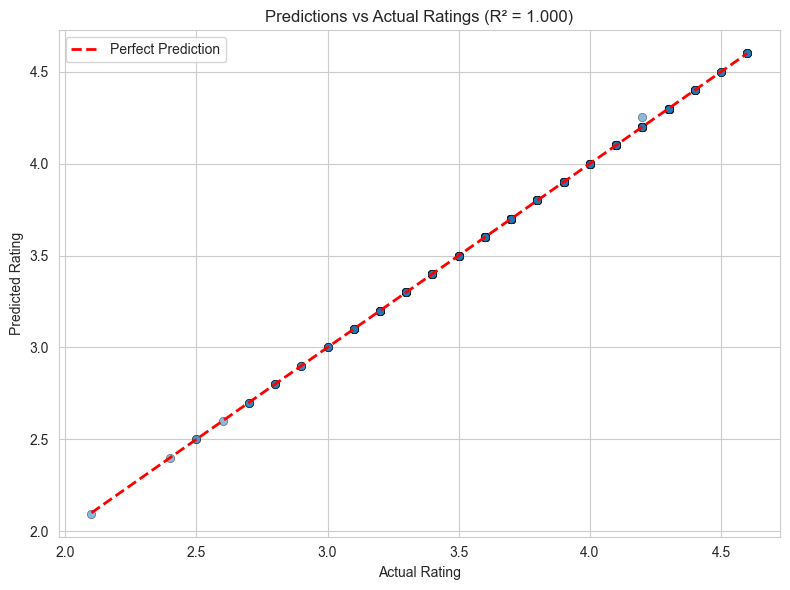

In [463]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
plt.scatter(y_test_final, y_pred_final, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_test_final.min(), y_test_final.max()], 
            [y_test_final.min(), y_test_final.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title(f'Predictions vs Actual Ratings (R² = {final_r2:.3f})')
plt.legend()
plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=100, bbox_inches='tight')
plt.show()



Feature Importance 

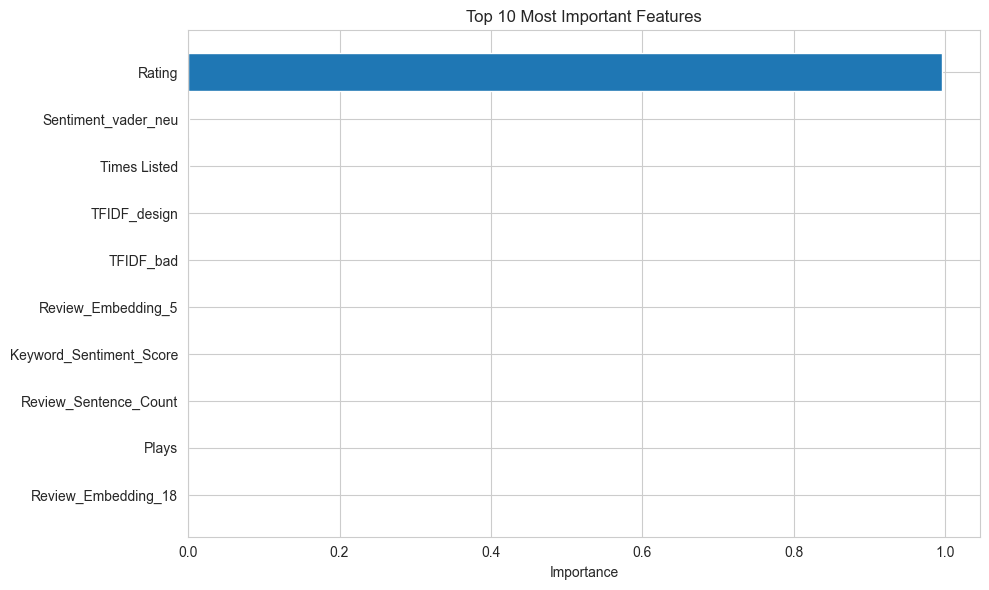

In [464]:

plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()


Model Comparison

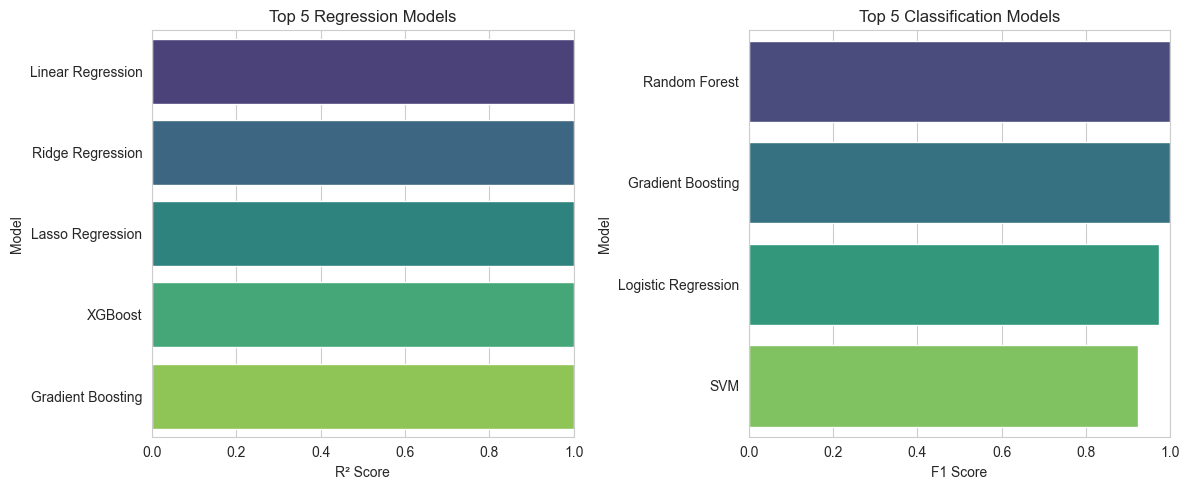

In [465]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
best_models = regression_df.head(5)
sns.barplot(data=best_models, x='R²', y='Model', palette='viridis')
plt.title('Top 5 Regression Models')
plt.xlabel('R² Score')
plt.xlim(0, 1)

if len(classification_df) > 0:
    plt.subplot(1, 2, 2)
    best_classifiers = classification_df.head(5)
    sns.barplot(data=best_classifiers, x='F1-Score', y='Model', palette='viridis')
    plt.title('Top 5 Classification Models')
    plt.xlabel('F1 Score')
    plt.xlim(0, 1)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
import joblib
import pickle

joblib.dump(best_model, 'best_model.pkl')

joblib.dump(scaler, 'scaler.pkl')

with open('features.pkl', 'wb') as f:
    pickle.dump(features_all, f)

print("✅ Model saved successfully!")
print(f"Model type: {type(best_model)}")
print(f"Number of features: {len(features_all)}")